In [1]:
"""
We're going to build our first full fledged Neural Networks with Tensorflow and
Keras

Regression
Predict House Price
  1. Square Footage
  2. number of bedrooms
  3. home age

Classification
Predicting whether a customer will churn (cancel)
  1. monthly bill
  2. support tickets
  3. months as a customer
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)

print("Setup complete")

Setup complete


In [2]:
# Let's start with our housing example and build our data

n_samples = 400

square_feet = np.random.randint(800, 3500, size=n_samples)
bedrooms = np.random.randint(1, 6, size=n_samples)
home_age = np.random.randint(0, 80, size=n_samples)
"""
our goal is to make real-ish data, larger homes tend to cost more, usually
more bedrooms is the same and older homes typically cost a little less

add some noise to vary the data a little
"""

noise = np.random.normal(0, 25000, size = n_samples)

# 400 realish samples
price = (
    50000
    + square_feet * 180
    + bedrooms * 15000
    - home_age * 1200
    + noise
)

# Let's make a dataframe for this for visualization
housing_df = pd.DataFrame({
    "square_feet": square_feet,
    "bedrooms": bedrooms,
    "home_age": home_age,
    "price": price
})

housing_df.head()

,square_feet,bedrooms,home_age,price
0,1660,2,26,401480.988461
1,2094,5,72,432326.432110
2,1930,2,25,381828.637422
3,1895,5,46,400446.424150
4,2438,1,55,405628.815506


       square_feet    bedrooms    home_age          price
count   400.000000  400.000000  400.000000     400.000000
mean   2163.402500    3.065000   37.532500  440664.254166
std     752.807078    1.478594   22.895621  141501.438160
min     801.000000    1.000000    0.000000  130340.744825
25%    1537.500000    2.000000   18.000000  329487.646907
50%    2179.500000    3.000000   37.000000  442438.833296
75%    2781.250000    4.000000   56.500000  550857.506293
max    3495.000000    5.000000   78.000000  776243.821179


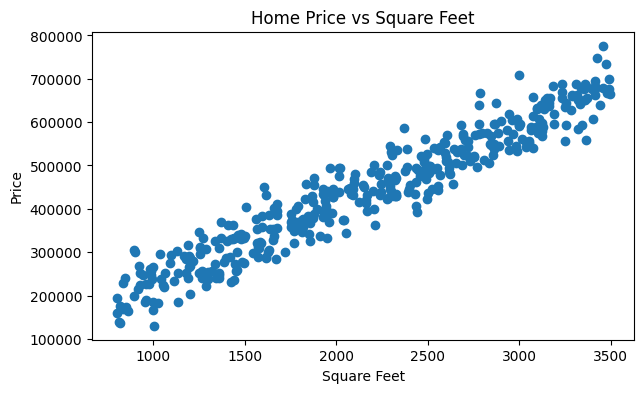

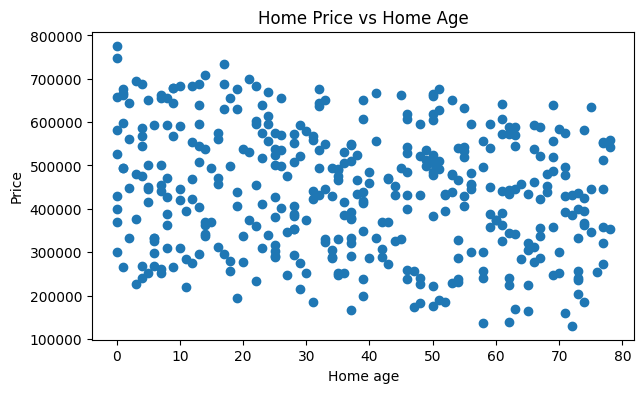

In [3]:
# Quick look at the data itself

print(housing_df.describe())

plt.figure(figsize=(7,4))
plt.scatter(housing_df["square_feet"], housing_df["price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Home Price vs Square Feet")
plt.show()

plt.figure(figsize=(7,4))
plt.scatter(housing_df["home_age"], housing_df["price"])
plt.xlabel("Home age")
plt.ylabel("Price")
plt.title("Home Price vs Home Age")
plt.show()

In [4]:
# Before we create our model, one final step in preprocessing and that's splitting our data

X_regression = housing_df[["square_feet", "bedrooms", "home_age"]].values
y_regression = housing_df["price"].values

# Split into train and test data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=.2,
    random_state=42
)

"""
We need to scale our data
Typically Neural networks perform better when the data is scaled down
This prevents things like one feature (like sq ft) from dominating other feature
(i.e 1800 sq ft vs 2 bedrooms)

There are a couple of different scalers but here we will use the StandardScaler
which returns the Z-Score of the value

Z-Score (don't confuse with weighted sum z) is value - mean / std
"""

regression_scaler = StandardScaler()

# ONLY FIT THE SCALER TO THE TRAIN DATA
# DO NOT FIT THE SCALER TO THE TEST DATA
# We'll need to transform both, but fitting to the test data cause test data
# leakage
# Test data leakage -> Getting a sneak peek at the test data before we're supposed to
X_train_reg_scaled = regression_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = regression_scaler.transform(X_test_reg)

print(X_train_reg[0])
print(X_test_reg_scaled[0])

[1895    5   46]
[ 1.07689039 -1.37238163  0.76498278]


In [5]:
"""
Let's build a neural network with Keras

Architecture (INITIAL):

3 input features -> Dense Hidden Layer with 2 neurons -> 1 output layer

For regression we do not need sigmoid or softmax
and since we want a linear value, we don't need another activation function in our output layer
"""

# Define the model
# OLD MODEL
# regression_model = tf.keras.Sequential([
#     tf.keras.layers.Input(shape=(3,)), # Input Layer
#     tf.keras.layers.Dense(2, activation='relu'), # Hidden Layer 1
#     tf.keras.layers.Dense(1) # Default function is linear (Output Layer)
# ])

regression_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)), # Input Layer
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'), # Hidden Layer 1
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1) # Default function is linear (Output Layer)
])

# Compile
regression_model.compile(
    # Optimizer
    # The optimizer tells TF HOW to update the weights
    optimizer=tf.keras.optimizers.Adam(learning_rate=.05),
    # Loss function
    # "Linear" Regression we probably want MSE (Mean Squared Error)
    loss = "mse",
    # Any metrics I want to track
    # Here we'll track absolute error or how far off we are from the actual price
    metrics=["mae"]
)


regression_model.summary()
# Fitting

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Just like scikit learn, after we define the model we need to fit it
regression_history = regression_model.fit(
    X_train_reg_scaled,
    y_train_reg,
    # Epochs is the number of forward passes on all the data
    epochs=100,
    # Validation Split (i.e how much training data should be used for the validation set)
    validation_split=.2,
    verbose=0
)

print("Regression Training Complete")

Regression Training Complete


Test MSE: 723,026,304.00
Test MAE: $21,472.63


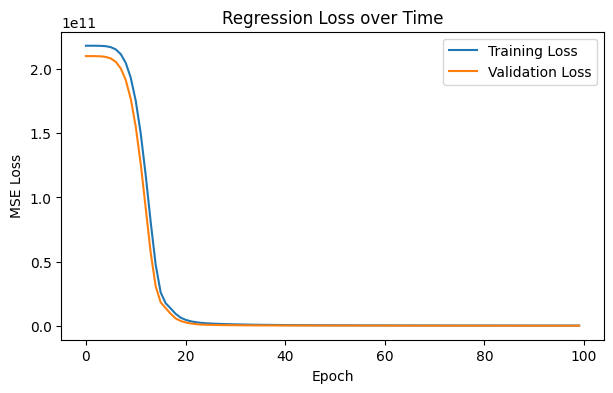

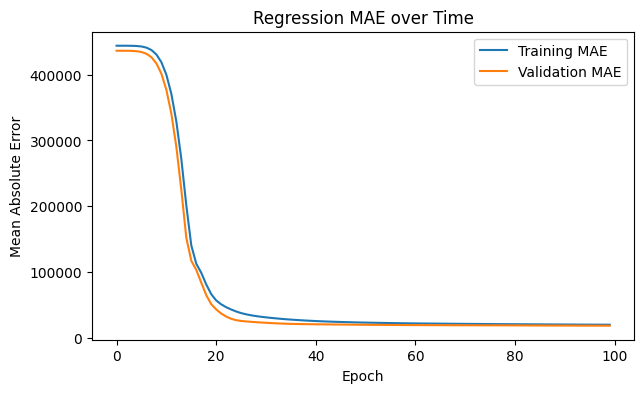

In [7]:
# Let's look at some metrics and see how we did!
reg_loss, reg_mae = regression_model.evaluate(
    X_test_reg_scaled,
    y_test_reg,
    verbose=0
)

print(f"Test MSE: {reg_loss:,.2f}")
print(f"Test MAE: ${reg_mae:,.2f}")

plt.figure(figsize=(7,4))
plt.plot(regression_history.history["loss"], label="Training Loss")
plt.plot(regression_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression Loss over Time")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(regression_history.history["mae"], label="Training MAE")
plt.plot(regression_history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.title("Regression MAE over Time")
plt.legend()
plt.show()

In [8]:
# Let's make some quick predictions

sample_homes = np.array([
    [1200, 2, 40],
    [2200, 3, 15],
    [3200, 5, 5],
    [1600, 5, 5]
])

# To predict we need to scale and then predict
sample_homes_scaled = regression_scaler.transform(sample_homes)
predicted_prices = regression_model.predict(sample_homes_scaled)

print(predicted_prices)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
[[242131.81]
 [472828.2 ]
 [698856.9 ]
 [405691.97]]


In [9]:
# Second motivating example:
#
# A company wants to predict whether a customer is likely to cancel.
#
# Features:
#   1. monthly_bill
#   2. support_tickets
#   3. months_as_customer
#
# Target:
#   churned
#       0 = stayed
#       1 = canceled/churned

n_customers = 500

monthly_bill = np.random.normal(85, 25, size=n_customers)
monthly_bill = np.clip(monthly_bill, 30, 180)

support_tickets = np.random.poisson(1.5, size=n_customers)
support_tickets = np.clip(support_tickets, 0, 8)

months_as_customer = np.random.randint(1, 72, size=n_customers)

# Create a probability of churn.
#
# Higher bill -> more likely to churn
# More support tickets -> more likely to churn
# Longer customer history -> less likely to churn

churn_score = (
    -2.0
    + 0.025 * monthly_bill
    + 0.45 * support_tickets
    - 0.035 * months_as_customer
)

churn_probability = 1 / (1 + np.exp(-churn_score))

churned = np.random.binomial(1, churn_probability)

churn_df = pd.DataFrame({
    "monthly_bill": monthly_bill,
    "support_tickets": support_tickets,
    "months_as_customer": months_as_customer,
    "churned": churned
})

churn_df.head()

,monthly_bill,support_tickets,months_as_customer,churned
0,57.760173,3,42,0
1,125.778146,3,61,1
2,65.709292,0,13,0
3,92.415708,3,11,1
4,110.128564,0,54,0


       monthly_bill  support_tickets  months_as_customer     churned
count    500.000000       500.000000          500.000000  500.000000
mean      84.455399         1.542000           36.734000    0.398000
std       24.426984         1.292896           20.264366    0.489976
min       30.000000         0.000000            1.000000    0.000000
25%       66.743091         1.000000           19.000000    0.000000
50%       84.736721         1.000000           38.000000    0.000000
75%      100.280888         2.000000           55.000000    1.000000
max      151.579559         7.000000           71.000000    1.000000

churned
0    301
1    199
Name: count, dtype: int64


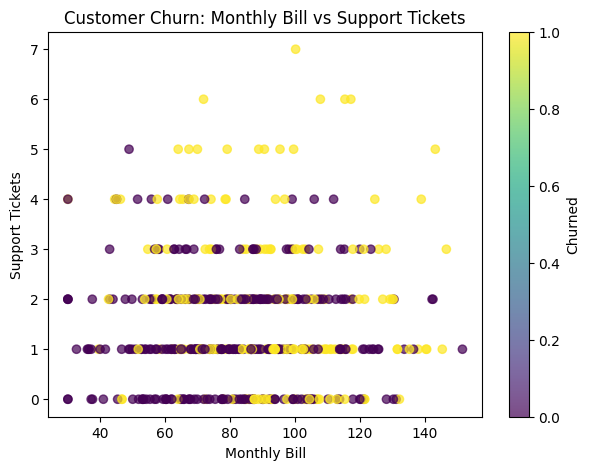

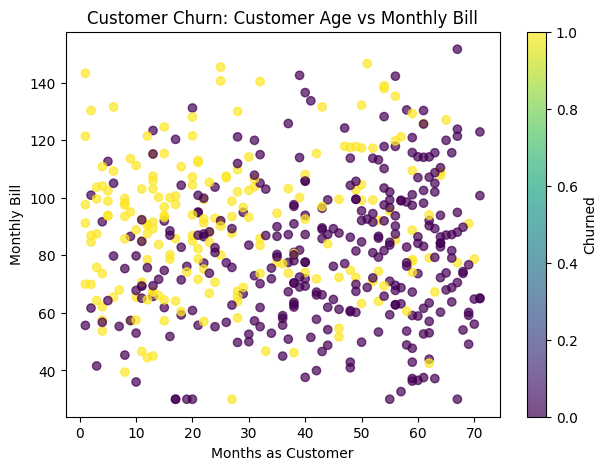

In [10]:

# Quick Look at the Classification Data


print(churn_df.describe())
print()
print(churn_df["churned"].value_counts())

plt.figure(figsize=(7, 5))
plt.scatter(
    churn_df["monthly_bill"],
    churn_df["support_tickets"],
    c=churn_df["churned"],
    alpha=0.7
)
plt.xlabel("Monthly Bill")
plt.ylabel("Support Tickets")
plt.title("Customer Churn: Monthly Bill vs Support Tickets")
plt.colorbar(label="Churned")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(
    churn_df["months_as_customer"],
    churn_df["monthly_bill"],
    c=churn_df["churned"],
    alpha=0.7
)
plt.xlabel("Months as Customer")
plt.ylabel("Monthly Bill")
plt.title("Customer Churn: Customer Age vs Monthly Bill")
plt.colorbar(label="Churned")
plt.show()

In [11]:
# Prepare Classification Features and Target

X_classification = churn_df[[
    "monthly_bill",
    "support_tickets",
    "months_as_customer"
]].values

y_classification = churn_df["churned"].values

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

classification_scaler = StandardScaler()

X_train_clf_scaled = classification_scaler.fit_transform(X_train_clf)
X_test_clf_scaled = classification_scaler.transform(X_test_clf)

print("Original first training row:", X_train_clf[0])
print("Scaled first training row:", X_train_clf_scaled[0])

Original first training row: [117.19956185   6.          52.        ]
Scaled first training row: [1.31322436 3.59513223 0.77496075]


In [12]:
# Architecture:
#
#   3 input features
#        ↓
#   Dense hidden layer with 8 neurons
#        ↓
#   Dense hidden layer with 8 neurons
#        ↓
#   Dense hidden layer with 4 neurons
#        ↓
#   1 output neuron
#
# For binary classification, the output layer uses sigmoid.
#
# Sigmoid squishes the output between 0 and 1.
# We can interpret this as a probability-like score.


# FIX THIS IT'S REALLY OVERFIT
classification_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

classification_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

classification_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the Classification Model

classification_history = classification_model.fit(
    X_train_clf_scaled,
    y_train_clf,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

print("Classification training complete.")

Classification training complete.


In [14]:
# Evaluate the Classification Model

clf_loss, clf_accuracy = classification_model.evaluate(
    X_test_clf_scaled,
    y_test_clf,
    verbose=0
)

print(f"Test Loss: {clf_loss:.4f}")
print(f"Test Accuracy: {clf_accuracy:.4f}")

Test Loss: 0.7783
Test Accuracy: 0.7100


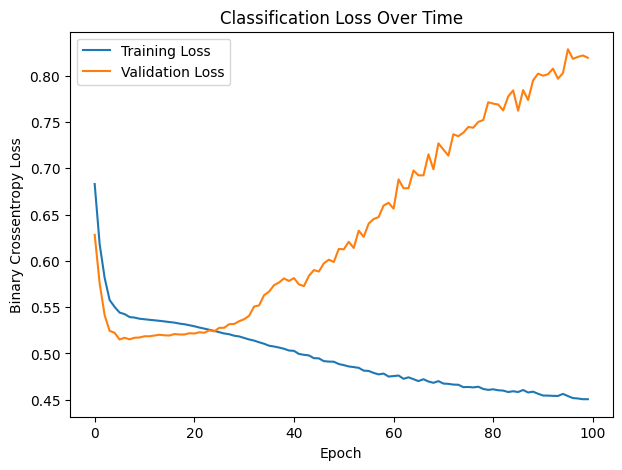

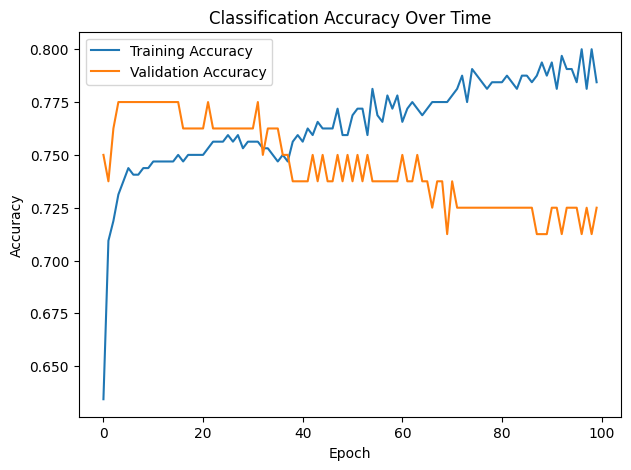

In [15]:
# Plot Classification Training History

plt.figure(figsize=(7, 5))
plt.plot(classification_history.history["loss"], label="Training Loss")
plt.plot(classification_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Classification Loss Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(classification_history.history["accuracy"], label="Training Accuracy")
plt.plot(classification_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classification Accuracy Over Time")
plt.legend()
plt.show()

In [16]:
# Classification Predictions
# ============================================================

sample_customers = np.array([
    [45, 0, 60],    # low bill, no issues, long-time customer
    [125, 5, 4],    # high bill, many issues, newer customer
    [90, 2, 24],    # middle case
])

sample_customers_scaled = classification_scaler.transform(sample_customers)

predicted_churn_probabilities = classification_model.predict(sample_customers_scaled)

for customer, probability in zip(sample_customers, predicted_churn_probabilities):
    monthly_bill, support_tickets, months_as_customer = customer
    predicted_class = 1 if probability[0] >= 0.5 else 0

    print(
        f"Customer: ${monthly_bill:.0f}/month, "
        f"{support_tickets:.0f} tickets, "
        f"{months_as_customer:.0f} months "
        f"=> Churn probability: {probability[0]:.2%}, "
        f"Predicted class: {predicted_class}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Customer: $45/month, 0 tickets, 60 months => Churn probability: 4.28%, Predicted class: 0
Customer: $125/month, 5 tickets, 4 months => Churn probability: 89.43%, Predicted class: 1
Customer: $90/month, 2 tickets, 24 months => Churn probability: 67.64%, Predicted class: 1


In [17]:
# Compare Regression vs Classification
#
# Same general Keras workflow:
#
#   1. Prepare X and y
#   2. Scale X
#   3. Build model
#   4. Compile model
#   5. Train with fit()
#   6. Evaluate
#   7. Predict
#
# Main differences:
#
# REGRESSION
#   Example target:
#       price
#   Output layer:
#       Dense(1)
#   Loss:
#       mse
#   Metric:
#       mae
#   Prediction:
#       a numeric value
#
# CLASSIFICATION
#   Example target:
#       churned or not churned
#   Output layer:
#       Dense(1, activation="sigmoid")
#   Loss:
#       binary_crossentropy
#   Metric:
#       accuracy
#   Prediction:
#       probability / class label
#